# Assignment 6: Decision Tree Regressor for Vulnerability Severity

| | |
|---|------------------|
| **student name** | Anshuman Atrey |
| **roll number** | 150096724029 · B.Tech CSE 2024-28, Semester V · Machine Learning Fundamentals (Google Classroom, ML(Elon Musk)) |
| **dataset name** | CVE (Common Vulnerabilities and Exposures), file `cve.csv` |
| **kaggle link** | https://www.kaggle.com/datasets/andrewkronser/cve-common-vulnerabilities-and-exposures |
| **rows x columns** | 89,660 rows x 13 columns |
| **target** | `cvss`, the official severity score of a vulnerability, from 0 (harmless) to 10 (critical) |
| **result** | **R-squared 0.9997** on the test set (MAE 0.001) |

## the whole thing in plain words

for anyone who has never touched machine learning:

1. **The task:** predict a software vulnerability's severity score (CVSS, from 0 to 10) with a Decision Tree Regressor.
2. **Why this dataset:** security teams fix the most dangerous problems first, and ranking findings by danger is exactly what Walrus Securitas (the company im building) does.
3. **The data:** 89,660 real published vulnerabilities from Kaggle, each with its official score and the 6 facts the score is built from.
4. **The 6 facts:** how the attacker gets in (over the network or only on the machine), how hard the attack is, whether a login is needed, and how badly it hurts the data's secrecy, its integrity, and the system staying up.
5. **Cleaning:** 884 vulnerabilities were missing those facts, so they were dropped, leaving 88,776. The text facts became 0/1 columns, since the tree needs numbers.
6. **What a decision tree does:** it's a flowchart of yes/no questions, like a hospital triage desk. Each path of answers ends in a predicted score.
7. **The first question it learned:** "can the attack fully take over the data's integrity?" If yes, the average score jumps to 8.8 out of 10. The next question is whether it works over the network.
8. **The result:** R² 0.9997 on vulnerabilities it never saw, with a typical error of 0.001 points.
9. **Why so accurate:** the official score is calculated by a fixed formula from those 6 facts, and only 287 different combinations appear. The tree rediscovered the official calculator from examples.
10. **What matters most:** the damage facts alone explain 79% of the score, the access facts alone only 16%. Severity is mostly about how much damage, not how the attacker gets in.
11. **The honest catch:** this only works once someone knows those 6 facts. Predicting the score from just the type of weakness is much harder.
12. **What gets handed in:** one Word document (plus a PDF copy) with my name, roll number, the dataset link, the code, output screenshots, results, plots and the conclusion.

## the idea in one minute

every published software vulnerability (a CVE) gets a CVSS severity score from 0 to 10, and security teams use it to decide what to fix first. at [Walrus Securitas](https://walrussecuritas.com/), the AI security testing platform im building, ranking findings by how dangerous they are is the core job. so the question here: **can a decision tree learn how severity gets scored, just from examples?**

a decision tree is a flowchart of yes/no questions, like a hospital triage desk: "is the patient conscious? is the bleeding heavy?" and each path ends in a decision. here the questions are about the vulnerability ("can it be attacked over the network? does it give full control of the data?") and each path ends in a severity score.

## 1. load and understand the dataset

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree

df = pd.read_csv("data/cve.csv").rename(columns={"Unnamed: 0": "cve_id"})
print("shape:", df.shape)
print("columns:", list(df.columns))
print("\nmissing values:", df.isna().sum()[lambda s: s > 0].to_dict())
df.head(3)

shape: (89660, 13)
columns: ['cve_id', 'mod_date', 'pub_date', 'cvss', 'cwe_code', 'cwe_name', 'summary', 'access_authentication', 'access_complexity', 'access_vector', 'impact_availability', 'impact_confidentiality', 'impact_integrity']

missing values: {'access_authentication': 884, 'access_complexity': 884, 'access_vector': 884, 'impact_availability': 884, 'impact_confidentiality': 884, 'impact_integrity': 884}


,cve_id,mod_date,pub_date,cvss,cwe_code,cwe_name,summary,access_authentication,access_complexity,access_vector,impact_availability,impact_confidentiality,impact_integrity
0,CVE-2019-16548,2019-11-21 15:15:00,2019-11-21 15:15:00,6.8,352,Cross-Site Request Forgery (CSRF),A cross-site request forgery vulnerability in ...,NaN,NaN,NaN,NaN,NaN,NaN
1,CVE-2019-16547,2019-11-21 15:15:00,2019-11-21 15:15:00,4.0,732,Incorrect Permission Assignment for Critical ...,Missing permission checks in various API endpo...,NaN,NaN,NaN,NaN,NaN,NaN
2,CVE-2019-16546,2019-11-21 15:15:00,2019-11-21 15:15:00,4.3,639,Authorization Bypass Through User-Controlled Key,Jenkins Google Compute Engine Plugin 4.1.1 and...,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df.dtypes.to_frame("type").T

,cve_id,mod_date,pub_date,cvss,cwe_code,cwe_name,summary,access_authentication,access_complexity,access_vector,impact_availability,impact_confidentiality,impact_integrity
type,object,object,object,float64,int64,object,object,object,object,object,object,object,object


89,660 vulnerabilities and 13 columns: the id, two dates, the `cvss` score (a number from 0 to 10), the weakness type (`cwe_code`, `cwe_name`), a text `summary`, and the 6 CVSS parts as text. the only missing values are in those 6 parts, the same 884 rows each time (the first rows above show they are recent 2019 CVEs that hadnt been fully scored yet).

## 2. prepare the dataset

- **input features (X):** the 6 parts the CVSS score is built from: how the attacker reaches it (`access_vector`), how hard the attack is (`access_complexity`), whether a login is needed (`access_authentication`), and how much it damages confidentiality, integrity and availability (`impact_*`)
- **target (y):** `cvss`
- **only the necessary preprocessing:** drop the rows where the 6 parts are missing, and one-hot encode them (each text value becomes its own 0/1 column), because the tree needs numbers

In [3]:
FEATURES = ["access_vector", "access_complexity", "access_authentication",
            "impact_confidentiality", "impact_integrity", "impact_availability"]
data = df.dropna(subset=FEATURES)
X = pd.get_dummies(data[FEATURES], dtype=int)
y = data["cvss"]
print(f"rows used: {len(data)} (dropped {len(df) - len(data)} with missing parts) | features: {X.shape[1]}")

rows used: 88776 (dropped 884 with missing parts) | features: 18


## 3. train-test split and the model

80% of the vulnerabilities to train, 20% to test. one Decision Tree Regressor, grown until its leaves are pure (`random_state` fixed so the result repeats).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
tree = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
pred = tree.predict(X_test)
print(f"train: {len(X_train)} | test: {len(X_test)} | tree leaves: {tree.get_n_leaves()}, depth: {tree.get_depth()}")

train: 71020 | test: 17756 | tree leaves: 268, depth: 11


## 4. evaluate the model

In [5]:
mse = mean_squared_error(y_test, pred)
results = pd.Series({"MAE": mean_absolute_error(y_test, pred), "MSE": mse, "RMSE": np.sqrt(mse),
                     "R2 (test)": r2_score(y_test, pred), "R2 (train)": tree.score(X_train, y_train)})
results.round(4).to_frame("score")

,score
MAE,0.0010
MSE,0.0011
RMSE,0.0334
R2 (test),0.9997
R2 (train),1.0000


**R² 0.9997** on the 17,756 test vulnerabilities, an average error (MAE) of 0.001 points and RMSE 0.033 on a 0 to 10 scale. train R² is 1.000 and test 0.9997, so theres no real gap: its not memorising, its learned a rule that also holds for vulnerabilities it never saw.

## 5. visualisations

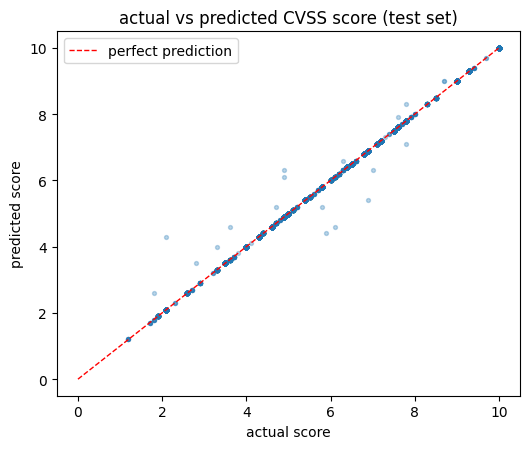

In [6]:
fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.scatter(y_test, pred, s=8, alpha=0.3)
ax.plot([0, 10], [0, 10], "r--", lw=1, label="perfect prediction")
ax.set(title="actual vs predicted CVSS score (test set)", xlabel="actual score", ylabel="predicted score")
ax.legend()
plt.tight_layout()
plt.savefig("figures/01_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

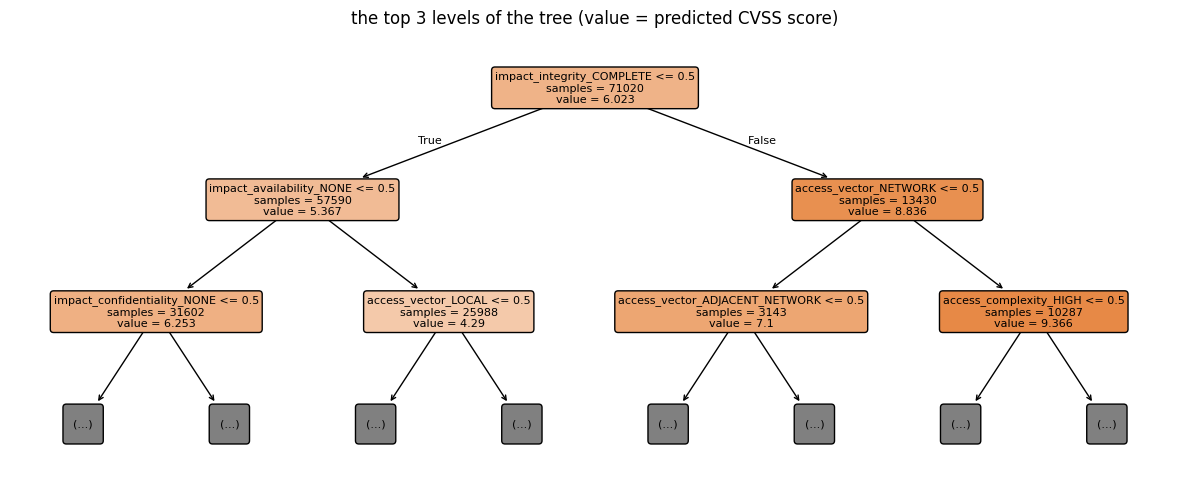

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(tree, max_depth=2, feature_names=X.columns, filled=True, impurity=False, rounded=True,
          fontsize=8, ax=ax)
ax.set_title("the top 3 levels of the tree (value = predicted CVSS score)")
plt.tight_layout()
plt.savefig("figures/02_tree_top_levels.png", dpi=150, bbox_inches="tight")
plt.show()

almost every point sits exactly on the diagonal. the handful of dots off it are vulnerabilities whose score doesnt match the usual one for their 6 parts (only 4 combinations ever got more than one score).

the tree's first question is the most telling: **"does it give the attacker complete control over the data's integrity?"** if yes (right branch), the average score is 8.8. then it asks whether it can be attacked over the network and whether the attack is hard, ending at 9.4 for the worst case. if no (left branch), it asks about availability and confidentiality next. the tree puts the damage questions first, which is exactly what the next section measures.

## 6. one observation: why is it this accurate?

In [8]:
combos = data.groupby(FEATURES)["cvss"].nunique()
print(f"different combinations of the 6 parts: {len(combos)} | combinations with more than one score: "
      f"{(combos > 1).sum()}")
for name, cols in {"impact parts only": FEATURES[3:], "access parts only": FEATURES[:3]}.items():
    Xs = pd.get_dummies(data[cols], dtype=int)
    part = DecisionTreeRegressor(random_state=42).fit(Xs.loc[X_train.index], y_train)
    print(f"{name}: test R2 {r2_score(y_test, part.predict(Xs.loc[X_test.index])):.3f}")

different combinations of the 6 parts: 287 | combinations with more than one score: 4
impact parts only: test R2 0.786
access parts only: test R2 0.155


only **287** different combinations of the 6 parts appear in 88,776 vulnerabilities, and only 4 of them ever got more than one score. thats because CVSS isnt a judgement call, its a fixed formula: the score is calculated from those 6 parts. the fully grown tree (268 leaves) has basically become a lookup table of that official calculator, which is why R² is almost exactly 1.

splitting the parts shows what drives severity: the **impact parts alone explain 79%** of the score, the **access parts alone only 16%**. how much damage a bug can do matters far more than how the attacker gets in.

## 7. conclusion

- **dataset used:** CVE (Common Vulnerabilities and Exposures) from kaggle, 89,660 vulnerabilities (88,776 after dropping rows with missing parts)
- **target predicted:** the CVSS severity score, 0 to 10
- **model performance:** MAE 0.001, MSE 0.0011, RMSE 0.033 on the test set
- **R² score:** 0.9997 on the test set (train 1.000)
- **one observation:** the score is a fixed formula of the 6 parts, and the tree rediscovered it from examples. the damage parts (79%) matter far more than the access parts (16%), and the tree's very first question is about integrity damage

being honest about the limit: this only works once someone already knows the 6 parts. in a quick side test outside this notebook, predicting the score from just the weakness type and year explained only about 35%, so scoring a brand new finding still needs someone to work out its impact first. for walrus thats the useful lesson: get the impact right, and the score follows.